
# Triadic Cell Notebook
## B / T / R in hardware terms

This notebook treats the triad as a machine:

- **Binding (B)** = state retention, register, latch, RAM cell
- **Transformation (T)** = transition rule, ALU/update step
- **Readout (R)** = bus, output, residue, emitted signal

The goal is simple:

1. build one `TriadicCell`
2. run it in four modes:
   - `BTR`
   - `BT`
   - `BR`
   - `TR`
3. see why the full triad behaves differently from pairwise cases

This is the software prototype of the claim that the three parts have to emerge as one.



## What this notebook is doing

A normal language model is mostly very strong at **T** and **R**.  
This notebook isolates the missing piece by making **B**, **T**, and **R** explicit inside one step.

We will track four signals:

- **coherence**: does the machine hold together?
- **state**: is it actually changing?
- **readout**: can the state be seen externally?
- **memory**: does readable difference accumulate?

This is a toy system, not a proof of physics.
It is a first executable shape.


In [1]:

from __future__ import annotations

from dataclasses import dataclass
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
np.set_printoptions(suppress=True, precision=4)

print("Notebook environment ready.")


Notebook environment ready.



## Hardware translation

In hardware language:

- **Binding** keeps a previous value alive long enough to matter.
- **Transformation** applies lawful change to that retained value.
- **Readout** exposes enough of the internal state that another system can couple to it.

If one leg is missing, the machine fails in a characteristic way:

- **BT**: internal evolution, but poor visibility
- **BR**: visible shell, but frozen logic
- **TR**: readable change, but weak identity retention


In [2]:

@dataclass
class TriadicState:
    coherence: float = 0.7   # durable identity / held-togetherness
    state: float = 0.2       # internal configuration
    readout: float = 0.0     # external legibility
    memory: float = 0.0      # retained readable difference


class TriadicCell:
    """
    One software cell with three explicit legs:
      B = binding / retention
      T = transformation / state update
      R = readout / emitted residue

    All values are clamped to [0, 1].
    """
    def __init__(self, B: float, T: float, R: float):
        self.B = float(B)
        self.T = float(T)
        self.R = float(R)

    @staticmethod
    def _clip(x: float) -> float:
        return float(np.clip(x, 0.0, 1.0))

    def step(self, s: TriadicState, drive: float) -> Tuple[TriadicState, float]:
        # B: state retention
        coherence = s.coherence + 0.08 * (self.B - 0.5) - 0.03 * abs(s.state - s.coherence)
        coherence = self._clip(coherence)

        # T: lawful change
        state = s.state + 0.16 * self.T * coherence - 0.08 * (1.0 - self.T)
        state = self._clip(state)

        # R: external visibility
        readout = self.R * max(coherence, state) * (0.55 + abs(state - s.state))
        readout = self._clip(readout)

        # memory of readable difference
        memory = s.memory + 0.15 * readout + 0.05 * abs(state - s.state)
        memory = self._clip(memory)

        next_state = TriadicState(
            coherence=coherence,
            state=state,
            readout=readout,
            memory=memory,
        )
        emitted = readout
        return next_state, emitted



## Drive signal

A machine needs something to respond to.

This input is just a smooth changing signal.  
Think of it like a clocked disturbance, data stream, or input pressure.


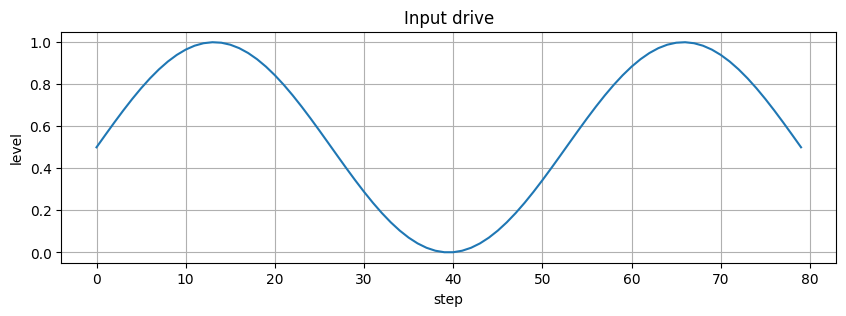

In [3]:

def make_drive(steps: int = 80) -> np.ndarray:
    t = np.linspace(0, 3 * np.pi, steps)
    return 0.5 + 0.5 * np.sin(t)

drive = make_drive(80)

plt.figure(figsize=(10, 3))
plt.plot(drive)
plt.title("Input drive")
plt.xlabel("step")
plt.ylabel("level")
plt.show()



## Run the four cases


In [4]:

def run_case(name: str, B: float, T: float, R: float, steps: int = 80) -> pd.DataFrame:
    cell = TriadicCell(B, T, R)
    s = TriadicState()
    rows: List[Dict[str, float]] = []

    for i, x in enumerate(make_drive(steps)):
        s, emitted = cell.step(s, float(x))
        rows.append({
            "step": i,
            "case": name,
            "B": B,
            "T": T,
            "R": R,
            "coherence": s.coherence,
            "state": s.state,
            "readout": s.readout,
            "memory": s.memory,
            "emitted": emitted,
        })

    return pd.DataFrame(rows)

cases = {
    "BTR": (1.0, 1.0, 1.0),
    "BT only": (1.0, 1.0, 0.0),
    "BR only": (1.0, 0.0, 1.0),
    "TR only": (0.0, 1.0, 1.0),
}

results = {name: run_case(name, *vals) for name, vals in cases.items()}
pd.concat(results.values(), ignore_index=True).head()


,step,case,B,T,R,coherence,state,readout,memory,emitted
0,0,BTR,1.0,1.0,1.0,0.725000,0.316000,0.482850,0.078227,0.482850
1,1,BTR,1.0,1.0,1.0,0.752730,0.436437,0.504658,0.159948,0.504658
2,2,BTR,1.0,1.0,1.0,0.783241,0.561755,0.528937,0.245555,0.528937
3,3,BTR,1.0,1.0,1.0,0.816597,0.692411,0.555821,0.335460,0.555821
4,4,BTR,1.0,1.0,1.0,0.852871,0.828870,0.585461,0.430103,0.585461


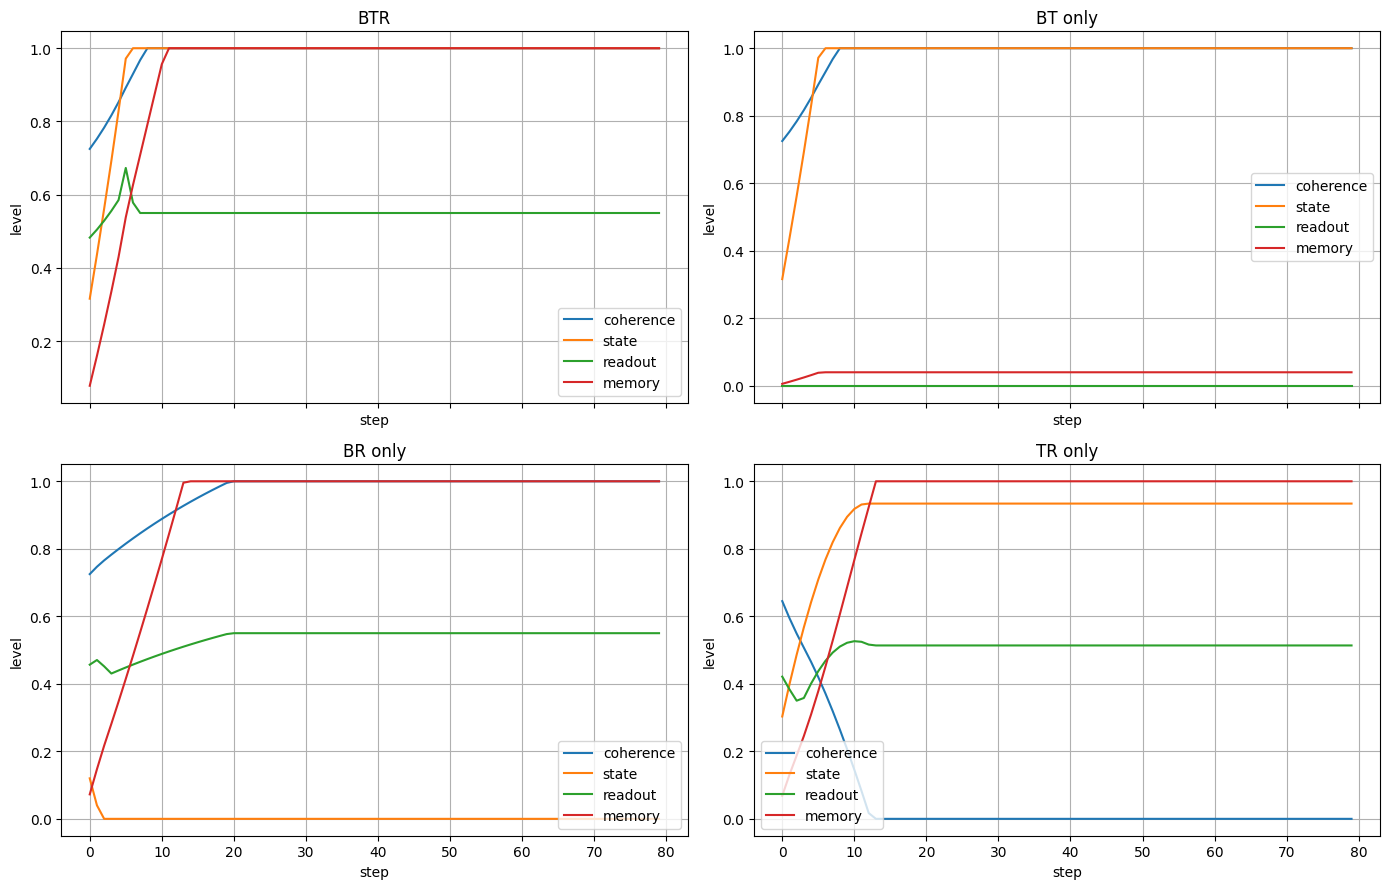

In [5]:

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True, sharey=False)
axes = axes.ravel()

for ax, (name, df) in zip(axes, results.items()):
    ax.plot(df["step"], df["coherence"], label="coherence")
    ax.plot(df["step"], df["state"], label="state")
    ax.plot(df["step"], df["readout"], label="readout")
    ax.plot(df["step"], df["memory"], label="memory")
    ax.set_title(name)
    ax.set_xlabel("step")
    ax.set_ylabel("level")
    ax.legend(loc="best")

plt.tight_layout()
plt.show()



## Read the plots

Interpretation:

- **BTR** should be the healthiest case because the system can hold itself, change, and expose the result.
- **BT only** can evolve internally, but nothing external can really lock onto it.
- **BR only** can look stable and visible, but it has little becoming.
- **TR only** can change and emit, but identity retention is weak.

This is the machine version of pairwise insufficiency.


In [6]:

summary = pd.DataFrame([
    {
        "case": name,
        "final_coherence": df["coherence"].iloc[-1],
        "final_state": df["state"].iloc[-1],
        "final_readout": df["readout"].iloc[-1],
        "final_memory": df["memory"].iloc[-1],
        "mean_coherence": df["coherence"].mean(),
        "mean_state": df["state"].mean(),
        "mean_readout": df["readout"].mean(),
        "mean_memory": df["memory"].mean(),
    }
    for name, df in results.items()
]).sort_values("mean_memory", ascending=False)

summary


,case,final_coherence,final_state,final_readout,final_memory,mean_coherence,mean_state,mean_readout,mean_memory
0,BTR,1.0,1.000000,0.550000,1.00,0.984000,0.972589,0.550740,0.934305
2,BR only,1.0,0.000000,0.550000,1.00,0.968568,0.002000,0.534567,0.917050
3,TR only,0.0,0.933931,0.513662,1.00,0.057338,0.897576,0.504079,0.914084
1,BT only,1.0,1.000000,0.000000,0.04,0.984000,0.972589,0.000000,0.038629



## Why this matters for AI

A plain transformer-based model is very strong at:

- pattern transformation
- readable output

That means it is naturally strongest in **T** and **R**.

What it is weaker at is durable, explicit runtime **B**:
- held identity
- persistent state
- memory of difference

So if you want a fold-native machine, you do not start by asking for prettier readout.
You start by making **Binding** explicit in the runtime.



## Next step: one cell becomes a chain

A real machine is not one cell.
It is many cells coupled across time.

The next experiment is:
- chain multiple triadic cells
- feed residue from one into the next
- add a persistent external memory object
- compare that against a plain transform/readout path


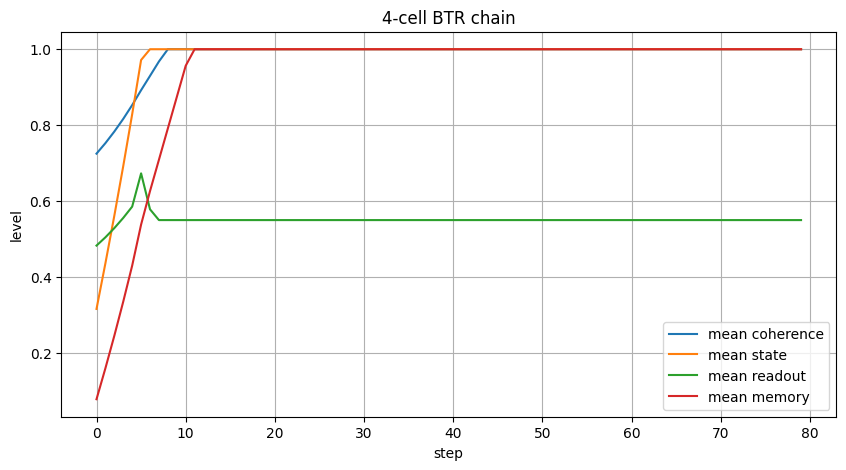

,step,input,final_emitted,mean_coherence,mean_state,mean_readout,mean_memory
75,75,0.729649,0.55,1.0,1.0,0.55,1.0
76,76,0.675155,0.55,1.0,1.0,0.55,1.0
77,77,0.618172,0.55,1.0,1.0,0.55,1.0
78,78,0.559509,0.55,1.0,1.0,0.55,1.0
79,79,0.500000,0.55,1.0,1.0,0.55,1.0


In [7]:

def run_chain(depth: int = 4, steps: int = 80, B: float = 1.0, T: float = 1.0, R: float = 1.0) -> pd.DataFrame:
    cells = [TriadicCell(B, T, R) for _ in range(depth)]
    states = [TriadicState() for _ in range(depth)]
    rows = []
    drive = make_drive(steps)

    for i, x in enumerate(drive):
        signal = float(x)
        for j, cell in enumerate(cells):
            states[j], signal = cell.step(states[j], signal)
        rows.append({
            "step": i,
            "input": x,
            "final_emitted": signal,
            "mean_coherence": np.mean([s.coherence for s in states]),
            "mean_state": np.mean([s.state for s in states]),
            "mean_readout": np.mean([s.readout for s in states]),
            "mean_memory": np.mean([s.memory for s in states]),
        })
    return pd.DataFrame(rows)

chain_df = run_chain(depth=4, steps=80, B=1.0, T=1.0, R=1.0)

plt.figure(figsize=(10, 5))
plt.plot(chain_df["step"], chain_df["mean_coherence"], label="mean coherence")
plt.plot(chain_df["step"], chain_df["mean_state"], label="mean state")
plt.plot(chain_df["step"], chain_df["mean_readout"], label="mean readout")
plt.plot(chain_df["step"], chain_df["mean_memory"], label="mean memory")
plt.title("4-cell BTR chain")
plt.xlabel("step")
plt.ylabel("level")
plt.legend(loc="best")
plt.show()

chain_df.tail()



## Closing compression

The translation is:

- **B** = what keeps the machine from dissolving
- **T** = what lets the machine become something else
- **R** = what lets another system read what happened

For a fold-native AI, these cannot be bolted together afterward.
They have to happen inside the same runtime event.

That is the reason this notebook starts with a triadic cell instead of a chatbot.
